# Postie Data Challenge — Analysis and Responses

This notebook builds on the initial exploratory analysis and focuses on answering the primary questions in the Postie data challenge.

## How to Read This Notebook

Each question begins with a short answer summary. The code and visualizations underneath provide supporting evidence. For a quick review, read the highlighted answer boxes and conclusions; the intermediate code cells are included for reproducibility.

## Challenge Questions Addressed

This notebook is organized around the questions provided in the challenge prompt:

1. Why was the reported `2017-07-03` sales value lower than the previous day’s sales summary?
2. What other key metrics should be reported for the system? Is average daily sales the right metric?
3. What information can be extracted from the URLs? Can all product prices be inferred?
4. Are there interesting purchasing combinations, events, or metrics worth reporting?
5. Can total sales for `2017-07-04` be predicted? How certain is the prediction?
6. What additional information, data, or access would improve the prediction?

In [47]:
# ------------------------------------------------------------
# Imports, paths, and cleaned data load
# ------------------------------------------------------------

from pathlib import Path
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from urllib.parse import urlparse, parse_qs, unquote_plus
from collections import Counter
from itertools import combinations
import datetime

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------

sns.set_theme(style="white", context="talk")

TITLE_STYLE = {
    "fontsize": 20,
    "fontweight": "bold",
    "pad": 18
}

AXIS_LABEL_STYLE = {
    "fontsize": 15,
    "fontweight": "bold",
    "labelpad": 10
}

TARGET_DATE = pd.to_datetime("2017-07-03").date()
PREDICTION_DATE = pd.to_datetime("2017-07-04").date()

TARGET_COLOR = "#F28E2B"  # orange highlight
GREY_COLORS = ["#cfcfcf", "#9f9f9f", "#6f6f6f", "#d9d9d9", "#b5b5b5"]

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------
target_date = pd.to_datetime("2017-07-03").date()
def plot_daily_bar(
    data,
    y_col,
    title,
    y_label,
    filename,
    money_axis=False,
    value_format="{:,.0f}",
    figsize=(10, 6)
):
    plot_data = data.copy().sort_values("date")
    
    colors = [
        TARGET_COLOR if date == target_date else GREY_COLORS[i % len(GREY_COLORS)]
        for i, date in enumerate(plot_data["date"])
    ]
    
    plt.figure(figsize=figsize)

    ax = sns.barplot(
        data=plot_data,
        x="date",
        y=y_col,
        palette=colors,
        hue="date",
        legend=False
    )

    for patch in ax.patches:
        height = patch.get_height()

        if money_axis:
            label = f"${height:,.0f}"
        else:
            label = value_format.format(height)

        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            label,
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.title(title, **TITLE_STYLE)
    plt.xlabel("Date", **AXIS_LABEL_STYLE)
    plt.ylabel(y_label, **AXIS_LABEL_STYLE)

    if money_axis:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
    else:
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

    plt.xticks(rotation=45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(False)
    sns.despine()

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Load cleaned transaction data
# ------------------------------------------------------------

cleaned_data_path = DATA_PROCESSED / "transactions_clean.csv"

df = pd.read_csv(cleaned_data_path)

# Restore analysis-friendly dtypes
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df["date"] = pd.to_datetime(df["date"], errors="coerce").dt.date
df["hour"] = pd.to_numeric(df["hour"], errors="coerce").astype("Int64")

df["website_id"] = pd.to_numeric(df["website_id"], errors="coerce").astype("Int64")
df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce").astype("Int64")
df["checkout_amount"] = pd.to_numeric(df["checkout_amount"], errors="coerce")

df["app_version"] = df["app_version"].astype("string")
df["url"] = df["url"].astype("string")
df["source_file"] = df["source_file"].astype("string")

# Confirmation
print(f"Loaded cleaned data: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Total sales: ${df['checkout_amount'].sum():,.2f}")
print(f"Missing timestamps: {df['timestamp'].isna().sum()}")
print(f"Missing checkout amounts: {df['checkout_amount'].isna().sum()}")

Loaded cleaned data: 33,188 rows x 11 columns
Date range: 2017-07-01 00:00:15+00:00 to 2017-07-03 23:59:57+00:00
Total sales: $588,850.00
Missing timestamps: 0
Missing checkout amounts: 0


<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 1: Why was the reported July 3 sales value lower than the previous day?
</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

The reported July 3 sales value appears low primarily because it does not match the UTC-normalized transaction-date total. The analyst reported `$164,065.00`, but after normalizing timestamps to UTC and grouping by transaction date, I calculate July 3 sales as `$181,583.00`.

Under this calculation, July 3 is only `$2,169` lower than July 2, a decrease of about `1.2%`, while transaction count actually increases. This suggests the original report overstated the size of the drop.

</div>

### Date Handling
The raw logs contain timezone-aware timestamps, so daily sales totals can change depending on whether records are grouped by the original source file/date or by a normalized transaction date.

When July 3 sales are calculated using the unnormalized/source-file grouping, the total is `$164,065.00`, which exactly matches the previously reported value. After normalizing timestamps to UTC and grouping by transaction date, July 3 sales increase to `$181,583.00`.

| Date | Total Sales | Transactions |
|:---|---:|---:|
| 2017-07-02 | $183,752 | 11,537 |
| 2017-07-03 | $181,583 | 11,748 |

Using UTC-normalized transaction dates, July 3 sales are much closer to July 2 than the reported value suggests. Total sales are slightly lower, but transaction volume is higher, which means July 3 does not appear to be a major drop in customer activity. Instead, the original reported value appears to reflect a date-boundary/source-file grouping difference.

### Note on Negative Checkout Amounts

July 3 also contains `17` negative checkout values. Each is exactly `-12`, for a total negative contribution of `-$204`.

These transactions are notable because they occur only on July 3 and appear across both website IDs and both app versions. They do not explain the full difference between `$164,065.00` and `$181,583.00`, but they are unusual enough to flag before finalizing revenue reporting.

If the `-12` values are valid negative revenue events, they should remain included. If they are errors and should be excluded, July 3 sales would increase to `$181,787`. If they are sign errors and should have been positive `$12` transactions, July 3 sales would increase to `$181,991`.

### Conclusion

The reported July 3 value appears lower than expected mainly because of date-boundary or timestamp handling. Once timestamps are normalized and transactions are grouped consistently, July 3 sales increase from `$164,065.00` to `$181,583.00`.

July 3 is still slightly lower than July 2 in total sales, but the gap is modest and occurs despite higher transaction volume. The evidence points more toward timestamp/date-boundary handling and transaction-value anomalies than a major decline in sales activity.

In [48]:
# ------------------------------------------------------------
# Investigate reported July 3 sales 
# ------------------------------------------------------------

# Analyst-reported value from the challenge prompt
reported_july_03_sales = 164_065.00
target_date = pd.to_datetime("2017-07-03").date()

# Make sure date fields exist
if "date" not in df.columns:
    df["date"] = df["timestamp"].dt.date

if "hour" not in df.columns:
    df["hour"] = df["timestamp"].dt.hour

if "day_of_week" not in df.columns:
    df["day_of_week"] = df["timestamp"].dt.day_name()

# ------------------------------------------------------------
# Daily summary
# ------------------------------------------------------------

daily_summary = (
    df.groupby("date")
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        min_order_value=("checkout_amount", "min"),
        max_order_value=("checkout_amount", "max"),
        unique_customers=("customer_id", "nunique"),
        unique_websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
        source_files=("source_file", "nunique"),
    )
    .reset_index()
    .sort_values("date")
)

# Add comparison columns
daily_summary["sales_change_vs_prior_day"] = daily_summary["total_sales"].diff()
daily_summary["sales_pct_change_vs_prior_day"] = daily_summary["total_sales"].pct_change()
daily_summary["transaction_change_vs_prior_day"] = daily_summary["transactions"].diff()
daily_summary["transaction_pct_change_vs_prior_day"] = daily_summary["transactions"].pct_change()

# Reproduce July 3 sales
july_03_row = daily_summary[daily_summary["date"] == target_date].copy()

if july_03_row.empty:
    print("No records found for 2017-07-03.")
else:
    computed_july_03_sales = july_03_row["total_sales"].iloc[0]
    difference_from_reported = computed_july_03_sales - reported_july_03_sales
    
    print("July 3 sales check")
    print("------------------")
    print(f"Reported July 3 sales: ${reported_july_03_sales:,.2f}")
    print(f"Computed July 3 sales: ${computed_july_03_sales:,.2f}")
    print(f"Difference: ${difference_from_reported:,.2f}")

July 3 sales check
------------------
Reported July 3 sales: $164,065.00
Computed July 3 sales: $181,583.00
Difference: $17,518.00


In [49]:
# ------------------------------------------------------------
# Negative checkout amount analysis
# ------------------------------------------------------------

negative_transactions = (
    df[df["checkout_amount"] < 0]
    .sort_values(["date", "timestamp"])
    [[
        "timestamp",
        "date",
        "hour",
        "website_id",
        "customer_id",
        "app_version",
        "checkout_amount",
        "url",
        "source_file",
    ]]
)

negative_daily_summary = (
    negative_transactions
    .groupby("date")
    .agg(
        negative_transaction_count=("checkout_amount", "size"),
        total_negative_checkout_value=("checkout_amount", "sum"),
        min_negative_checkout_value=("checkout_amount", "min"),
        max_negative_checkout_value=("checkout_amount", "max"),
        unique_negative_values=("checkout_amount", "nunique"),
        affected_customers=("customer_id", "nunique"),
        affected_websites=("website_id", "nunique"),
        affected_app_versions=("app_version", "nunique"),
    )
    .reset_index()
)

# Optional: include all dates, even days with no negative transactions
all_dates = pd.DataFrame({"date": sorted(df["date"].dropna().unique())})

negative_daily_summary = (
    all_dates
    .merge(negative_daily_summary, on="date", how="left")
    .fillna({
        "negative_transaction_count": 0,
        "total_negative_checkout_value": 0,
        "min_negative_checkout_value": 0,
        "max_negative_checkout_value": 0,
        "unique_negative_values": 0,
        "affected_customers": 0,
        "affected_websites": 0,
        "affected_app_versions": 0,
    })
)

print("Negative checkout summary by day:")
display(negative_daily_summary)

print("Negative checkout transaction details:")
negative_transactions

Negative checkout summary by day:


,date,negative_transaction_count,total_negative_checkout_value,min_negative_checkout_value,max_negative_checkout_value,unique_negative_values,affected_customers,affected_websites,affected_app_versions
0,2017-07-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2017-07-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2017-07-03,17.0,-204.0,-12.0,-12.0,1.0,17.0,2.0,2.0


Negative checkout transaction details:


,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,url,source_file
23435,2017-07-03 00:27:19+00:00,2017-07-03,0,124,10678,1.1,-12.0,http://xyz.com/checkout?European+Grape=1&Round...,2017-07-03.csv
23957,2017-07-03 01:28:04+00:00,2017-07-03,1,124,10186,1.1,-12.0,http://xyz.com/checkout?Ume=1&Natal+Orange=1,2017-07-03.csv
24744,2017-07-03 03:10:05+00:00,2017-07-03,3,124,10152,1.1,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Black%...,2017-07-03.csv
25473,2017-07-03 04:37:32+00:00,2017-07-03,4,123,10814,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&Euro...,2017-07-03.csv
25745,2017-07-03 05:10:47+00:00,2017-07-03,5,123,10462,1.2,-12.0,http://store.example.com/?Hazelnut=1&Mabolo=1,2017-07-03.csv
25826,2017-07-03 05:21:34+00:00,2017-07-03,5,123,10586,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&Euro...,2017-07-03.csv
25946,2017-07-03 05:36:29+00:00,2017-07-03,5,124,10064,1.2,-12.0,http://xyz.com/checkout?Bignay=2,2017-07-03.csv
25988,2017-07-03 05:41:52+00:00,2017-07-03,5,123,10885,1.2,-12.0,http://store.example.com/?Round+Kumquat=1&Ylan...,2017-07-03.csv
26369,2017-07-03 06:30:39+00:00,2017-07-03,6,124,10580,1.2,-12.0,http://xyz.com/checkout?Round+Kumquat=1&Black%...,2017-07-03.csv
26983,2017-07-03 07:49:50+00:00,2017-07-03,7,124,10998,1.2,-12.0,http://xyz.com/checkout?European+Grape=1&Round...,2017-07-03.csv


<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 2: The new analyst would also like a report detailing other key metrics for the system. Other than the average sales value per day, are there any other metrics that they should be using? Is an average sales value the right metric to use? Explain why/why not.
</div>
<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

Average sales value is useful, but it should not be used alone. The checkout amount distribution is skewed, with a small number of very large transactions that can pull the average away from a typical checkout value.

For this system, I would report average order value alongside total sales, transaction count, median order value, and anomaly/high-value transaction counts. I would also include website and app-version breakdowns when investigating changes across days.

</div>

### Why Average Sales Alone Is Not Enough

The daily median checkout amount is stable at `$6.00` across all three days, while the average order value varies more noticeably. This suggests that average sales value is being influenced by the upper tail of the transaction distribution rather than reflecting a large change in the typical transaction.

| Date | Transactions | Total Sales | Avg Order Value | Median Order Value |
|:---|---:|---:|---:|---:|
| 2017-07-01 | 9,903 | $223,515 | $22.57 | $6.00 |
| 2017-07-02 | 11,537 | $183,752 | $15.93 | $6.00 |
| 2017-07-03 | 11,748 | $181,583 | $15.46 | $6.00 |

This means average order value is informative, but incomplete. A change in average sales could reflect a true shift in customer behavior, or it could simply reflect a few unusually large purchases.

### Potential Additional Metrics of Interest

| Metric | Why I would report it |
|:---|:---|
| **Total sales** | Overall daily revenue. |
| **Transaction count** | Shows whether revenue changed because of volume. |
| **Average order value** | Useful revenue-per-transaction metric, but outlier-sensitive. |
| **Median order value** | Better representation of a typical checkout. |
| **High-value transaction count / contribution** | Shows whether totals are being driven by large outliers. |
| **Negative or unusual checkout counts** | Flags possible refunds, promotions, corrections, or logging issues. |
| **Website and app-version breakdowns** | Helps determine whether changes are system-wide or isolated to part of the system. |


### Conclusion

Average sales value is a useful metric, but it is not the right metric to use by itself. Because checkout amounts are skewed, the average can move even when the typical checkout amount remains unchanged.

A better daily report would pair average order value with total sales, transaction count, median order value, and anomaly/outlier checks. For debugging or diagnosing changes, I would also break these metrics down by website and app version.

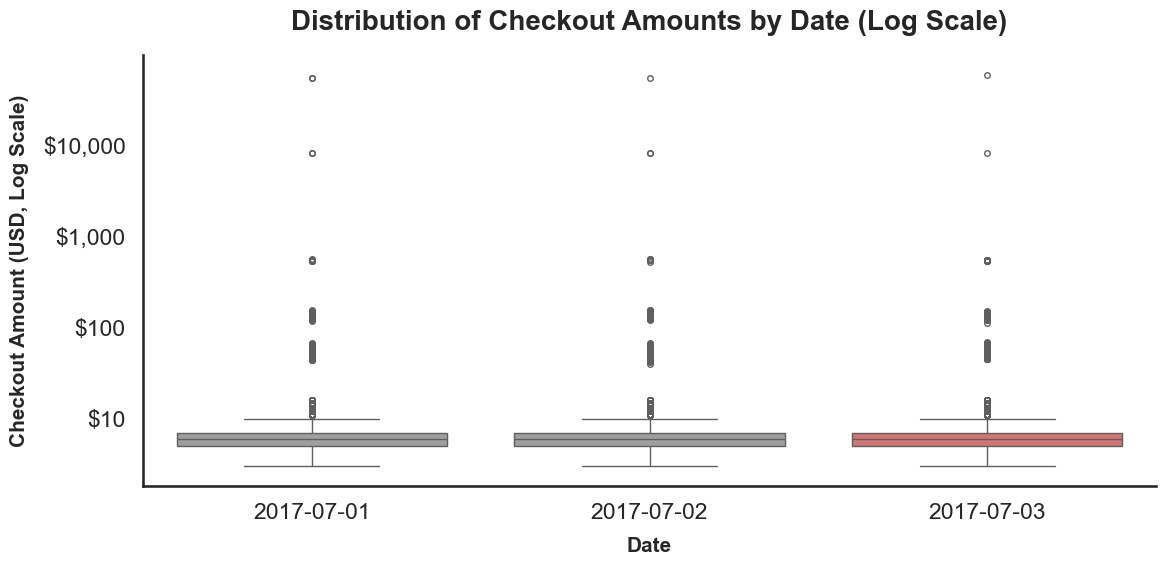

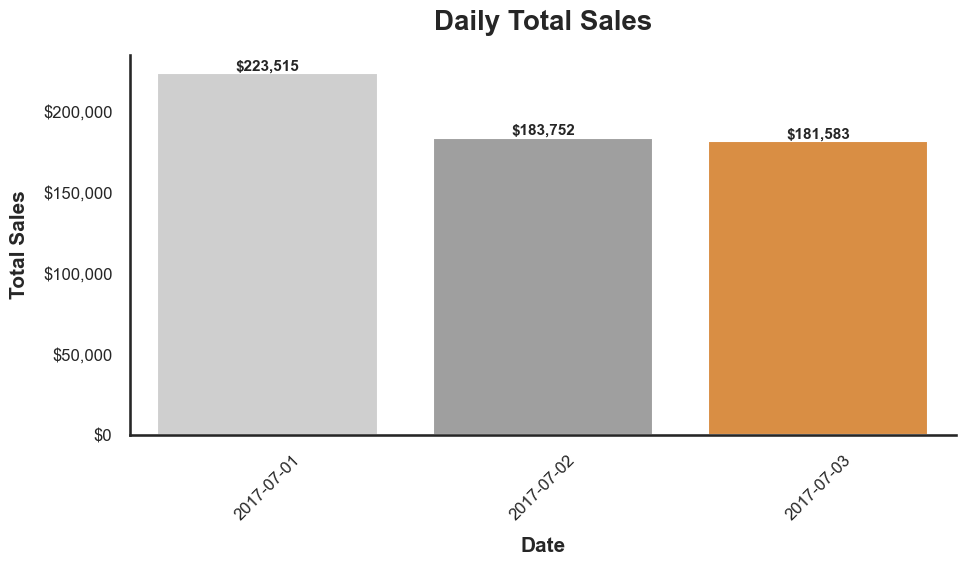

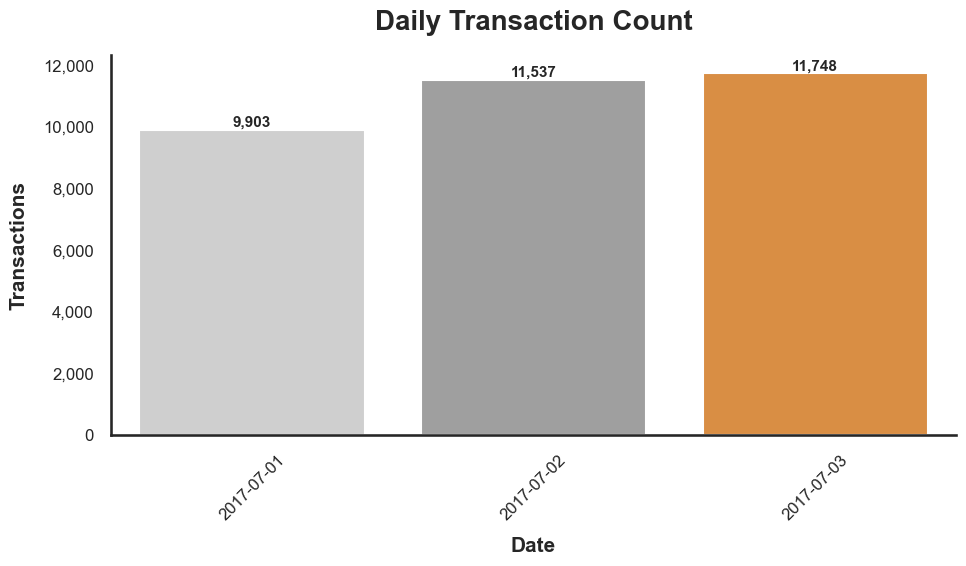

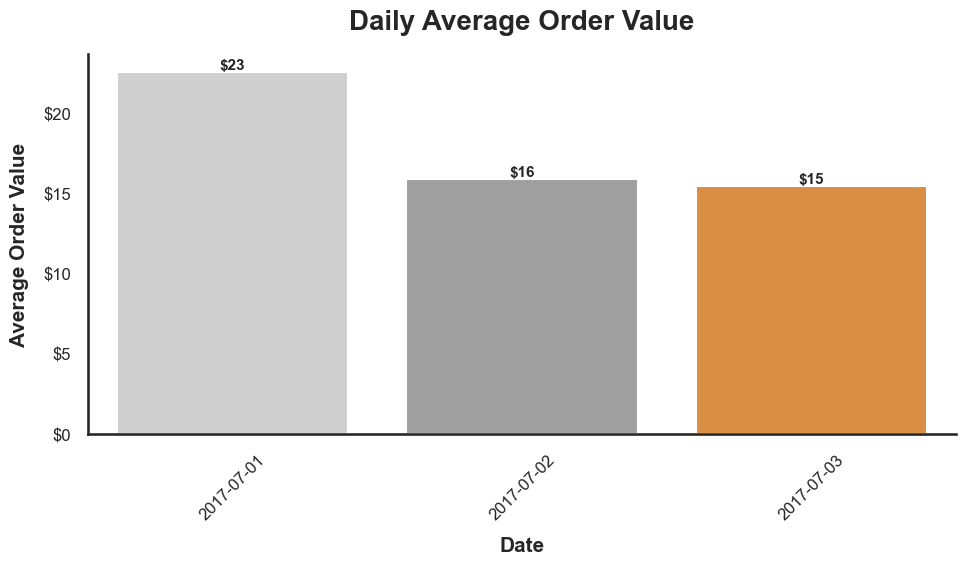

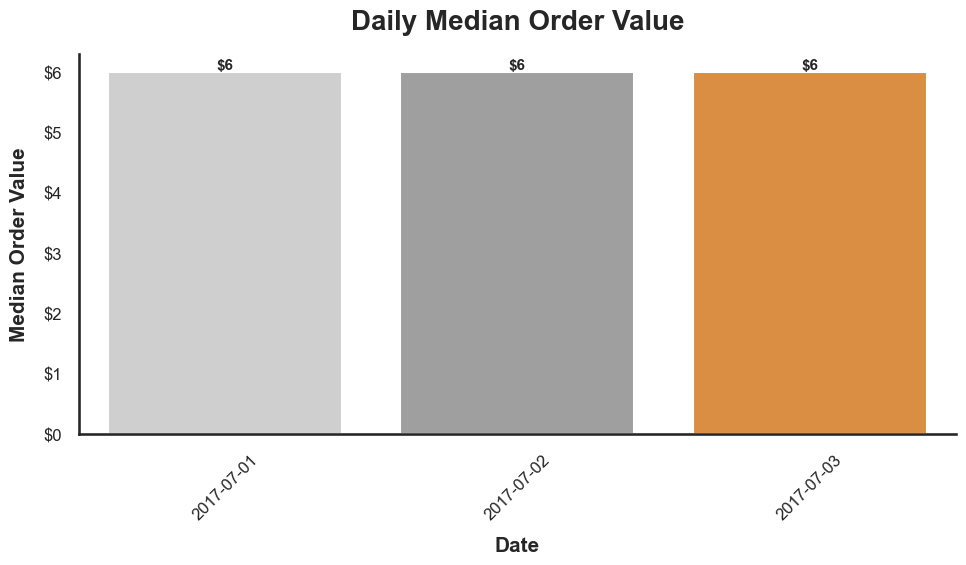

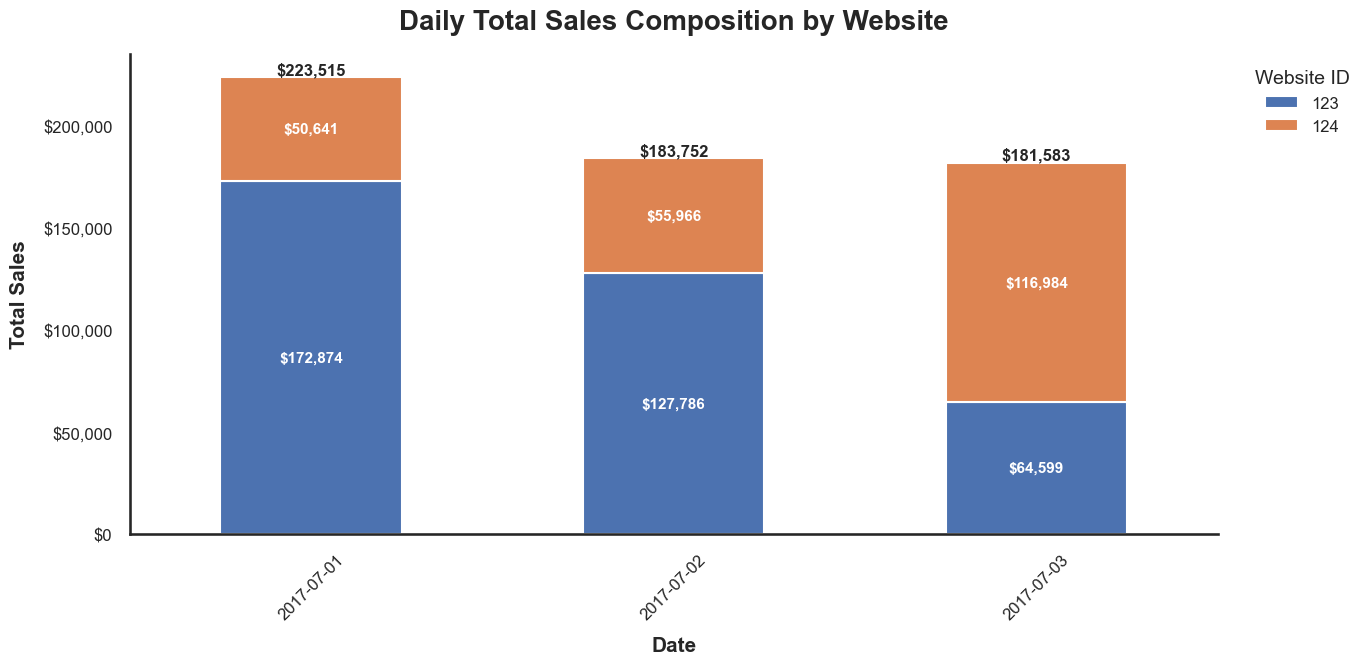

In [50]:
plt.figure(figsize=(12, 6))

# Map x to hue and set legend=False to satisfy the new Seaborn requirements
sns.boxplot(
    data=df, 
    x="date", 
    y="checkout_amount", 
    hue="date",  # <--- Added to map the color palette cleanly
    palette=["#9f9f9f" if d != datetime.date(2017, 7, 3) else "#E06666" for d in sorted(df["date"].unique())],
    legend=False,  # <--- Added to suppress the redundant legend
    fliersize=4
)

plt.yscale("log")
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

# Cleaned up plt.title to unpack TITLE_STYLE cleanly without argument conflicts
plt.title("Distribution of Checkout Amounts by Date (Log Scale)", **TITLE_STYLE)
plt.xlabel("Date", **AXIS_LABEL_STYLE)
plt.ylabel("Checkout Amount (USD, Log Scale)", **AXIS_LABEL_STYLE)

# Clean formatting
plt.grid(False)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

plot_daily_bar(
    data=daily_summary,
    y_col="total_sales",
    title="Daily Total Sales",
    y_label="Total Sales",
    filename="daily_total_sales.png",
    money_axis=True
)

plot_daily_bar(
    data=daily_summary,
    y_col="transactions",
    title="Daily Transaction Count",
    y_label="Transactions",
    filename="daily_transaction_count.png"
)

plot_daily_bar(
    data=daily_summary,
    y_col="average_order_value",
    title="Daily Average Order Value",
    y_label="Average Order Value",
    filename="daily_average_order_value.png",
    money_axis=True
)

plot_daily_bar(
    data=daily_summary,
    y_col="median_order_value",
    title="Daily Median Order Value",
    y_label="Median Order Value",
    filename="daily_median_order_value.png",
    money_axis=True
)

# Summarize sales by date and website
website_daily = (
    df.groupby(["date", "website_id"])
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        unique_customers=("customer_id", "nunique"),
    )
    .reset_index()
    .sort_values(["date", "website_id"])
)


# Create stacked sales table by website
website_sales_pivot = website_daily.pivot_table(
    index="date",
    columns="website_id",
    values="total_sales",
    aggfunc="sum",
    fill_value=0
)

# Clean website IDs for legend
website_sales_pivot.columns = [
    str(int(col)) if pd.notna(col) else str(col)
    for col in website_sales_pivot.columns
]

ax = website_sales_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

# Add white labels inside each website segment
for container in ax.containers:
    labels = [
        f"${value:,.0f}" if value > 0 else ""
        for value in container.datavalues
    ]
    
    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

# Add total labels above each stacked bar
daily_totals = website_sales_pivot.sum(axis=1)

for i, total in enumerate(daily_totals):
    ax.text(
        i,
        total,
        f"${total:,.0f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Daily Total Sales Composition by Website",
    fontsize=20,
    fontweight="bold",
    pad=18
)

plt.xlabel(
    "Date",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

plt.ylabel(
    "Total Sales",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))

plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

plt.grid(False)
sns.despine()

plt.legend(
    title="Website ID",
    title_fontsize=14,
    fontsize=12,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 3: What information can you extract from the URLs? Can you infer all product prices? Is there any other information that you believe would be useful to understand what is going on?

</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

The URLs are highly useful because they encode cart contents directly in the query string. From the URLs, I can extract product names, product quantities, cart size, product combinations, website/domain patterns, and malformed or unusual checkout behavior.

Product prices can be inferred for the normal product rows, and the inferred prices appear consistent across both websites. However, I would not blindly infer prices from every URL because at least one malformed/error-like URL is associated with an extreme checkout value.

</div>

### What Can Be Extracted from the URLs?

The URL query strings appear to encode cart contents as product/count pairs. This allows each transaction to be decomposed into the products purchased and their quantities.

From the URLs, I can extract:

- product names,
- product quantities,
- number of distinct products in the cart,
- total item quantity,
- product combinations,
- website/domain and checkout path patterns,
- and malformed or unusual URL/query behavior.

This is useful because it moves the analysis beyond daily totals. Instead of only asking whether sales changed, the URL data allows me to ask which products, quantities, or cart patterns contributed to sales behavior.

### Important Anomaly: Malformed URL Behavior

One important caveat is that not every URL behaves like a normal product cart. At least one transaction contains malformed or error-like URL information and is associated with a very large checkout amount.

This matters because product price inference depends on the assumption that the URL accurately represents the cart. If a URL contains an error token, malformed query string, or incomplete cart information, then the checkout amount should not be used as normal evidence for product pricing.

### Can Product Prices Be Inferred?

For normal single-product transactions, yes. Single-product carts provide a direct way to infer unit price by dividing checkout amount by quantity.

Based on those transactions, the inferred product prices are:

| Product | Inferred Unit Price |
|:---|---:|
| Bignay | $6 |
| Black/White Pepper | $5 |
| European Grape | $5 |
| Hazelnut | $4 |
| Mabolo | $8 |
| Natal Orange | $6 |
| Prairie Potato | $3 |
| Round Kumquat | $7 |
| Ume | $6 |
| Ylang-ylang | $5 |

For nearly all website/product combinations, the minimum, median, and maximum observed unit prices are identical. This suggests that normal product prices are consistent across websites.

The main exception is a `Bignay` transaction on website `124` with an observed unit price of `$60,000`. Since the median Bignay price is still `$6`, and the row appears tied to malformed/error-like URL behavior, I would treat it as an anomaly rather than a true product price.

### Additional Useful Information

The URL-derived cart data would also be useful for:

| Information | Why it matters |
|:---|:---|
| **Product quantities** | Helps explain large checkout amounts and bulk purchases. |
| **Product combinations** | Shows which products are commonly purchased together. |
| **Cart size** | Separates simple purchases from larger carts. |
| **Malformed URLs** | Flags possible logging or checkout issues. |
| **Product-level revenue** | Allows sales to be decomposed by product, not just by day. |
| **Website/app-version breakdowns** | Helps determine whether patterns are system-wide or isolated. |

### Conclusion

The URLs provide enough information to reconstruct cart contents and infer normal product prices. The inferred prices appear consistent across both websites.

However, product price inference should be done after filtering or flagging malformed URLs, negative checkout amounts, and extreme checkout values. So my answer is: product prices can be inferred for normal transactions, but not every URL should be treated as reliable without validation.

In [51]:
# ------------------------------------------------------------
# Inspect URL examples by website
# ------------------------------------------------------------

for website_id in sorted(df["website_id"].dropna().unique()):
    print(f"\nWebsite ID: {website_id}")
    print("=" * 100)
    
    examples = (
        df[df["website_id"] == website_id]
        [["url", "checkout_amount", "date", "app_version"]]
        .drop_duplicates("url")
        .head(3)
    )
    
    for _, row in examples.iterrows():
        print(f"Date: {row['date']} | App: {row['app_version']} | Amount: ${row['checkout_amount']:,.2f}")
        print(row["url"])
        print("-" * 100)


Website ID: 123
Date: 2017-07-01 | App: 1.1 | Amount: $6.00
http://www.example.com/store/?Natal+Orange=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 | Amount: $5.00
http://www.example.com/store/?Black%2FWhite+Pepper=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 | Amount: $12.00
http://www.example.com/store/?Ume=1&Natal+Orange=1
----------------------------------------------------------------------------------------------------

Website ID: 124
Date: 2017-07-01 | App: 1.1 | Amount: $6.00
http://xyz.com/checkout?Bignay=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 | Amount: $6.00
http://xyz.com/checkout?Ume=1
----------------------------------------------------------------------------------------------------
Date: 2017-07-01 | App: 1.1 

In [52]:
# ------------------------------------------------------------
# Parse product names and quantities from URL query strings
# ------------------------------------------------------------

from urllib.parse import urlparse, parse_qs, unquote_plus

def parse_url_products(url):
    """
    Parse product names and quantities from a checkout URL.

    Returns a dictionary:
        {product_name: quantity}
    """
    if pd.isna(url):
        return {}
    
    parsed = urlparse(str(url))
    query = parsed.query
    
    if not query:
        return {}
    
    parsed_query = parse_qs(query, keep_blank_values=True)
    
    products = {}
    for raw_product, raw_quantity in parsed_query.items():
        product = unquote_plus(raw_product).strip()
        
        # parse_qs returns values as lists
        quantity_value = raw_quantity[0] if raw_quantity else None
        
        try:
            quantity = int(quantity_value)
        except (TypeError, ValueError):
            quantity = np.nan
        
        products[product] = quantity
    
    return products


df["url_domain"] = df["url"].apply(lambda x: urlparse(str(x)).netloc if pd.notna(x) else None)
df["url_path"] = df["url"].apply(lambda x: urlparse(str(x)).path if pd.notna(x) else None)
df["product_quantities"] = df["url"].apply(parse_url_products)

df["num_distinct_products"] = df["product_quantities"].apply(len)
df["total_product_quantity"] = df["product_quantities"].apply(
    lambda d: sum(q for q in d.values() if pd.notna(q))
)

df[
    [
        "url",
        "url_domain",
        "url_path",
        "product_quantities",
        "num_distinct_products",
        "total_product_quantity",
        "checkout_amount",
    ]
].head(10)

,url,url_domain,url_path,product_quantities,num_distinct_products,total_product_quantity,checkout_amount
0,http://xyz.com/checkout?Bignay=1,xyz.com,/checkout,{'Bignay': 1},1,1,6.0
1,http://xyz.com/checkout?Ume=1,xyz.com,/checkout,{'Ume': 1},1,1,6.0
2,http://xyz.com/checkout?Natal+Orange=1,xyz.com,/checkout,{'Natal Orange': 1},1,1,6.0
3,http://www.example.com/store/?Natal+Orange=1,www.example.com,/store/,{'Natal Orange': 1},1,1,6.0
4,http://xyz.com/checkout?Hazelnut=1,xyz.com,/checkout,{'Hazelnut': 1},1,1,4.0
5,http://xyz.com/checkout?Round+Kumquat=1,xyz.com,/checkout,{'Round Kumquat': 1},1,1,7.0
6,http://xyz.com/checkout?Ylang-ylang=1,xyz.com,/checkout,{'Ylang-ylang': 1},1,1,5.0
7,http://www.example.com/store/?Black%2FWhite+Pe...,www.example.com,/store/,{'Black/White Pepper': 1},1,1,5.0
8,http://www.example.com/store/?Ume=1&Natal+Oran...,www.example.com,/store/,"{'Ume': 1, 'Natal Orange': 1}",2,2,12.0
9,http://xyz.com/checkout?Round+Kumquat=1,xyz.com,/checkout,{'Round Kumquat': 1},1,1,7.0


In [53]:
# ------------------------------------------------------------
# Create transaction-product-level table
# ------------------------------------------------------------

product_rows = []

for idx, row in df.iterrows():
    for product, quantity in row["product_quantities"].items():
        product_rows.append({
            "transaction_index": idx,
            "timestamp": row["timestamp"],
            "date": row["date"],
            "hour": row["hour"],
            "website_id": row["website_id"],
            "customer_id": row["customer_id"],
            "app_version": row["app_version"],
            "checkout_amount": row["checkout_amount"],
            "url_domain": row["url_domain"],
            "url_path": row["url_path"],
            "product": product,
            "quantity": quantity,
            "url": row["url"],
        })

product_df = pd.DataFrame(product_rows)

print(f"Product-level rows: {len(product_df):,}")
print(f"Unique products: {product_df['product'].nunique():,}")

product_df.head(10)

Product-level rows: 46,336
Unique products: 11


,transaction_index,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,url_domain,url_path,product,quantity,url
0,0,2017-07-01 07:00:05+00:00,2017-07-01,7,124,9221,1.1,6.0,xyz.com,/checkout,Bignay,1.0,http://xyz.com/checkout?Bignay=1
1,1,2017-07-01 07:00:14+00:00,2017-07-01,7,124,1639,1.1,6.0,xyz.com,/checkout,Ume,1.0,http://xyz.com/checkout?Ume=1
2,2,2017-07-01 00:00:15+00:00,2017-07-01,0,124,8272,1.1,6.0,xyz.com,/checkout,Natal Orange,1.0,http://xyz.com/checkout?Natal+Orange=1
3,3,2017-07-01 00:00:18+00:00,2017-07-01,0,123,6921,1.1,6.0,www.example.com,/store/,Natal Orange,1.0,http://www.example.com/store/?Natal+Orange=1
4,4,2017-07-01 00:00:19+00:00,2017-07-01,0,124,9219,1.1,4.0,xyz.com,/checkout,Hazelnut,1.0,http://xyz.com/checkout?Hazelnut=1
5,5,2017-07-01 00:00:28+00:00,2017-07-01,0,124,8451,1.1,7.0,xyz.com,/checkout,Round Kumquat,1.0,http://xyz.com/checkout?Round+Kumquat=1
6,6,2017-07-01 00:00:32+00:00,2017-07-01,0,124,6079,1.1,5.0,xyz.com,/checkout,Ylang-ylang,1.0,http://xyz.com/checkout?Ylang-ylang=1
7,7,2017-07-01 07:00:34+00:00,2017-07-01,7,123,5267,1.1,5.0,www.example.com,/store/,Black/White Pepper,1.0,http://www.example.com/store/?Black%2FWhite+Pe...
8,8,2017-07-01 07:00:37+00:00,2017-07-01,7,123,10151,1.1,12.0,www.example.com,/store/,Ume,1.0,http://www.example.com/store/?Ume=1&Natal+Oran...
9,8,2017-07-01 07:00:37+00:00,2017-07-01,7,123,10151,1.1,12.0,www.example.com,/store/,Natal Orange,1.0,http://www.example.com/store/?Ume=1&Natal+Oran...


In [54]:
# ------------------------------------------------------------
# Product-level summary
# ------------------------------------------------------------

product_summary = (
    product_df
    .groupby("product")
    .agg(
        transactions=("transaction_index", "nunique"),
        total_quantity=("quantity", "sum"),
        avg_quantity=("quantity", "mean"),
        min_quantity=("quantity", "min"),
        max_quantity=("quantity", "max"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
    )
    .reset_index()
    .sort_values(["transactions", "total_quantity"], ascending=False)
)

product_summary.head(20)

,product,transactions,total_quantity,avg_quantity,min_quantity,max_quantity,avg_checkout_amount,median_checkout_amount,websites,app_versions
5,Natal Orange,4755,9633.0,2.025868,1.0,999.0,70.758991,6.0,2,2
1,Black/White Pepper,4733,9766.0,2.063385,1.0,1049.0,70.028101,5.0,2,2
7,Round Kumquat,4666,9615.0,2.060652,1.0,1011.0,72.442778,7.0,2,2
6,Prairie Potato,4652,9576.0,2.058469,1.0,1013.0,69.417025,3.0,2,2
0,Bignay,4625,9547.0,2.064216,1.0,1003.0,84.893405,6.0,2,2
4,Mabolo,4611,9649.0,2.092605,1.0,1059.0,73.612232,8.0,2,2
9,Ylang-ylang,4596,9588.0,2.086162,1.0,1035.0,71.160574,5.0,2,2
2,European Grape,4585,9567.0,2.086587,1.0,1011.0,71.872192,5.0,2,2
3,Hazelnut,4580,9667.0,2.110699,1.0,1015.0,70.983843,4.0,2,2
8,Ume,4532,9617.0,2.122021,1.0,1008.0,73.780450,6.0,2,2


In [55]:
# Inspect rows where the parsed product is "error"

error_product_rows = product_df[
    product_df["product"].str.lower() == "error"
].copy()

error_product_rows[
    [
        "timestamp",
        "date",
        "hour",
        "website_id",
        "customer_id",
        "app_version",
        "checkout_amount",
        "product",
        "quantity",
        "url",
    ]
]

,timestamp,date,hour,website_id,customer_id,app_version,checkout_amount,product,quantity,url
37854,2017-07-03 07:59:32+00:00,2017-07-03,7,124,8553,1.2,60000.0,error,NaN,http://xyz.com/checkout?Bignay=1&error=True


In [59]:
# Product summary excluding rows with missing quantity

product_summary_clean = (
    product_df[product_df["quantity"].notna()]
    .groupby("product")
    .agg(
        transactions=("transaction_index", "nunique"),
        total_quantity=("quantity", "sum"),
        avg_quantity=("quantity", "mean"),
        min_quantity=("quantity", "min"),
        max_quantity=("quantity", "max"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        websites=("website_id", "nunique"),
        app_versions=("app_version", "nunique"),
    )
    .reset_index()
    .sort_values(["transactions", "total_quantity"], ascending=False)
)

product_summary_clean

,product,transactions,total_quantity,avg_quantity,min_quantity,max_quantity,avg_checkout_amount,median_checkout_amount,websites,app_versions
5,Natal Orange,4755,9633.0,2.025868,1.0,999.0,70.758991,6.0,2,2
1,Black/White Pepper,4733,9766.0,2.063385,1.0,1049.0,70.028101,5.0,2,2
7,Round Kumquat,4666,9615.0,2.060652,1.0,1011.0,72.442778,7.0,2,2
6,Prairie Potato,4652,9576.0,2.058469,1.0,1013.0,69.417025,3.0,2,2
0,Bignay,4625,9547.0,2.064216,1.0,1003.0,84.893405,6.0,2,2
4,Mabolo,4611,9649.0,2.092605,1.0,1059.0,73.612232,8.0,2,2
9,Ylang-ylang,4596,9588.0,2.086162,1.0,1035.0,71.160574,5.0,2,2
2,European Grape,4585,9567.0,2.086587,1.0,1011.0,71.872192,5.0,2,2
3,Hazelnut,4580,9667.0,2.110699,1.0,1015.0,70.983843,4.0,2,2
8,Ume,4532,9617.0,2.122021,1.0,1008.0,73.780450,6.0,2,2


### Product Price Inference Approach

The URL query strings appear to encode cart contents as product/count pairs. This means each transaction can be treated as a small cart equation:

`checkout_amount = quantity_1 × price_1 + quantity_2 × price_2 + ...`

I do not want to assume upfront that product prices are identical across websites, so I evaluate price inference in two ways:

1. infer one global price per product across all transactions,
2. infer product prices separately by website.


In [60]:
# ------------------------------------------------------------
# Prepare product/cart data for price inference
# ------------------------------------------------------------

price_product_df = product_df.copy()

price_product_df["quantity"] = pd.to_numeric(price_product_df["quantity"], errors="coerce")
price_product_df["checkout_amount"] = pd.to_numeric(price_product_df["checkout_amount"], errors="coerce")

# Keep only rows that look like valid product/quantity rows
valid_product_rows = price_product_df[
    (price_product_df["product"].notna()) &
    (price_product_df["quantity"].notna()) &
    (price_product_df["quantity"] > 0) &
    (price_product_df["checkout_amount"].notna())
].copy()

# Exclude malformed "error" product rows from product price inference
valid_product_rows = valid_product_rows[
    valid_product_rows["product"].str.lower() != "error"
].copy()

# Start with positive checkout transactions for clean price inference
# Negative values are investigated separately because they may be refunds/adjustments/errors.
valid_product_rows_positive = valid_product_rows[
    valid_product_rows["checkout_amount"] > 0
].copy()

print(f"Valid product rows for price inference: {len(valid_product_rows_positive):,}")
print(f"Unique products: {valid_product_rows_positive['product'].nunique():,}")
print(f"Transactions represented: {valid_product_rows_positive['transaction_index'].nunique():,}")

Valid product rows for price inference: 46,301
Unique products: 10
Transactions represented: 33,167


In [61]:
# ------------------------------------------------------------
# Single-product cart price check
# ------------------------------------------------------------

# Reconstruct cart-level counts from the valid product rows
cart_product_counts = (
    valid_product_rows_positive
    .groupby(["transaction_index", "product"], as_index=False)
    .agg(
        quantity=("quantity", "sum"),
        checkout_amount=("checkout_amount", "first"),
        website_id=("website_id", "first"),
        date=("date", "first"),
        app_version=("app_version", "first"),
        url=("url", "first"),
    )
)

cart_summary = (
    cart_product_counts
    .groupby("transaction_index")
    .agg(
        distinct_products=("product", "nunique"),
        total_quantity=("quantity", "sum"),
        checkout_amount=("checkout_amount", "first"),
        website_id=("website_id", "first"),
        date=("date", "first"),
        app_version=("app_version", "first"),
        url=("url", "first"),
    )
    .reset_index()
)

single_product_carts = cart_product_counts.merge(
    cart_summary[["transaction_index", "distinct_products"]],
    on="transaction_index",
    how="left"
)

single_product_carts = single_product_carts[
    single_product_carts["distinct_products"] == 1
].copy()

single_product_carts["observed_unit_price"] = (
    single_product_carts["checkout_amount"] / single_product_carts["quantity"]
)

single_product_price_summary = (
    single_product_carts
    .groupby(["website_id", "product"])
    .agg(
        single_product_transactions=("transaction_index", "nunique"),
        min_observed_price=("observed_unit_price", "min"),
        median_observed_price=("observed_unit_price", "median"),
        max_observed_price=("observed_unit_price", "max"),
        unique_observed_prices=("observed_unit_price", "nunique"),
    )
    .reset_index()
    .sort_values(["website_id", "product"])
)

single_product_price_summary

,website_id,product,single_product_transactions,min_observed_price,median_observed_price,max_observed_price,unique_observed_prices
0,123,Bignay,1474,6.0,6.0,6.0,1
1,123,Black/White Pepper,1462,5.0,5.0,5.0,1
2,123,European Grape,1433,5.0,5.0,5.0,1
3,123,Hazelnut,1392,4.0,4.0,4.0,1
4,123,Mabolo,1448,8.0,8.0,8.0,1
5,123,Natal Orange,1458,6.0,6.0,6.0,1
6,123,Prairie Potato,1439,3.0,3.0,3.0,1
7,123,Round Kumquat,1476,7.0,7.0,7.0,1
8,123,Ume,1401,6.0,6.0,6.0,1
9,123,Ylang-ylang,1414,5.0,5.0,5.0,1


<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 4: Are there any interesting purchasing combinations, events, or metrics that are worth reporting and displaying? What information should the analyst know about the system that you’ve uncovered?

</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

The most important findings are not only purchasing combinations, but also system-level events and data behaviors that affect how sales should be interpreted.

The analyst should know that the reported July 3 sales discrepancy appears tied to date-boundary/source-file grouping, July 3 contains repeated `-12` checkout amounts, at least one malformed/error-like URL is tied to an extreme checkout value, and July 3 is also the only day with an app version transition.

From the purchasing data, most carts are single-product purchases, product prices appear stable for normal transactions, and product mix is fairly balanced across days. This suggests July 3’s lower sales are not obviously explained by a dramatic product-mix shift.

</div>

### System Events and Data Behaviors Worth Reporting

| Finding | Why it matters |
|:---|:---|
| **Date-boundary/source-file mismatch** | The originally reported July 3 value matches source-file grouping, while UTC-normalized transaction-date grouping gives a higher July 3 total. |
| **Repeated `-12` checkout amounts** | These occur only on July 3 and appear across websites and app versions, making them worth investigating before final revenue reporting. |
| **Malformed/error-like URL tied to an extreme checkout amount** | This suggests that URL parsing and product-price inference should include anomaly handling. |
| **App version transition on July 3** | July 3 includes both app version `1.1` and `1.2`, so app-version behavior should be considered when diagnosing that day. |
| **Skewed checkout distribution** | A small number of very large transactions can materially affect total sales and average order value. |

### Purchasing Patterns Worth Reporting

The URL-derived cart data adds useful context beyond daily sales totals. It shows that most transactions are simple carts, often containing a single product. This helps explain why product prices can be inferred cleanly from single-product transactions.

At the same time, larger multi-product carts exist and have much higher checkout values. These are worth reporting separately because they can disproportionately influence daily sales and average order value.

Useful purchasing metrics include:

| Metric | Why it is useful |
|:---|:---|
| **Cart size distribution** | Shows whether transactions are mostly simple purchases or larger multi-product carts. |
| **Median checkout amount by cart size** | Shows how checkout value changes as carts become more complex. |
| **Product mix by day** | Tests whether a day’s sales pattern is driven by a shift in what products were purchased. |
| **Product mix deviation from even share** | Makes small product-mix shifts easier to identify. |
| **High-quantity carts** | Helps explain unusually large checkout amounts. |
| **Malformed URL/query counts** | Helps separate normal purchasing behavior from data-quality or logging issues. |

### Product Mix Interpretation

The product mix appears fairly balanced across days. There are small shifts in individual products, but no single product appears to dominate July 3 in a way that would clearly explain the lower total sales.

This is important because it suggests July 3’s sales pattern is more likely related to date handling, order-value distribution, transaction anomalies, or system behavior than to a major shift toward lower-priced products.

### Cart Size Interpretation

The cart-size distribution is also useful. Most transactions are single-product carts, which represent typical purchasing behavior and support reliable product-price inference.

Larger carts are much less common, but they have higher median checkout amounts and may contribute disproportionately to revenue. Because of this, I would report cart size and high-quantity cart behavior alongside daily sales totals.

### Conclusion

The analyst should know that the most important uncovered issues are a mix of business behavior and data/system behavior. Product-level analysis is useful, but the biggest interpretation risks come from date-boundary handling, anomalous transaction values, malformed URLs, outliers, and the July 3 app-version transition.

For reporting, I would include daily sales and transaction metrics, but also add anomaly counts, cart-size distribution, product mix, high-value transaction monitoring, website/app-version breakdowns, and URL parsing validation.

In [62]:
# ------------------------------------------------------------
# Common product combinations
# ------------------------------------------------------------

cart_products = (
    product_df[
        (product_df["product"].notna()) &
        (product_df["product"].str.lower() != "error") &
        (product_df["quantity"].notna()) &
        (product_df["quantity"] > 0)
    ]
    .groupby(["transaction_index", "date"])
    .agg(
        products=("product", lambda x: tuple(sorted(set(x)))),
        distinct_products=("product", "nunique"),
        checkout_amount=("checkout_amount", "first"),
        total_quantity=("quantity", "sum"),
    )
    .reset_index()
)

product_combinations = (
    cart_products
    .groupby("products")
    .agg(
        transactions=("transaction_index", "nunique"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        avg_total_quantity=("total_quantity", "mean"),
        days_observed=("date", "nunique"),
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

product_combinations["product_combination"] = product_combinations["products"].apply(
    lambda x: " + ".join(x)
)

# ------------------------------------------------------------
# Most common multi-product cart combinations
# ------------------------------------------------------------

multi_product_combinations = (
    product_combinations[
        product_combinations["products"].apply(len) > 1
    ]
    .copy()
)

multi_product_combinations_display = multi_product_combinations[
    [
        "product_combination",
        "transactions",
        "avg_checkout_amount",
        "median_checkout_amount",
        "avg_total_quantity",
        "days_observed",
    ]
].head(15)

multi_product_combinations_display

,product_combination,transactions,avg_checkout_amount,median_checkout_amount,avg_total_quantity,days_observed
5,Bignay + Black/White Pepper + European Grape +...,161,1485.993789,140.0,270.0,3
575,Prairie Potato + Ylang-ylang,71,8.000000,8.0,2.0,3
412,Black/White Pepper + Hazelnut,70,9.000000,9.0,2.0,3
1,Bignay + Black/White Pepper,70,11.000000,11.0,2.0,3
550,Hazelnut + Prairie Potato,67,7.000000,7.0,2.0,3
303,Bignay + Mabolo,66,14.000000,14.0,2.0,3
529,Hazelnut + Mabolo,65,11.630769,12.0,2.0,3
569,Natal Orange + Round Kumquat,64,13.000000,13.0,2.0,3
564,Mabolo + Ylang-ylang,64,13.000000,13.0,2.0,3
522,European Grape + Prairie Potato,64,8.000000,8.0,2.0,3


In [63]:
# ------------------------------------------------------------
# Cart size distribution
# ------------------------------------------------------------

cart_size_summary = (
    cart_products
    .groupby("distinct_products")
    .agg(
        transactions=("transaction_index", "nunique"),
        avg_checkout_amount=("checkout_amount", "mean"),
        median_checkout_amount=("checkout_amount", "median"),
        avg_total_quantity=("total_quantity", "mean"),
        median_total_quantity=("total_quantity", "median"),
        days_observed=("date", "nunique"),
    )
    .reset_index()
    .sort_values("distinct_products")
)

cart_size_summary

,distinct_products,transactions,avg_checkout_amount,median_checkout_amount,avg_total_quantity,median_total_quantity,days_observed
0,1,28868,7.637904,6.0,1.010496,1.0,3
1,2,2562,10.806011,11.0,2.000000,2.0,3
2,3,3,47.000000,49.0,10.000000,10.0,3
3,4,18,55.166667,55.0,10.000000,10.0,3
4,5,198,55.055556,55.0,10.000000,10.0,3
5,6,506,54.954545,55.0,10.000000,10.0,3
6,7,491,55.940937,55.0,10.122200,10.0,3
7,8,240,68.454167,56.0,12.500000,10.0,3
8,9,141,125.468085,134.0,22.978723,25.0,3
9,10,161,1485.993789,140.0,270.000000,25.0,3


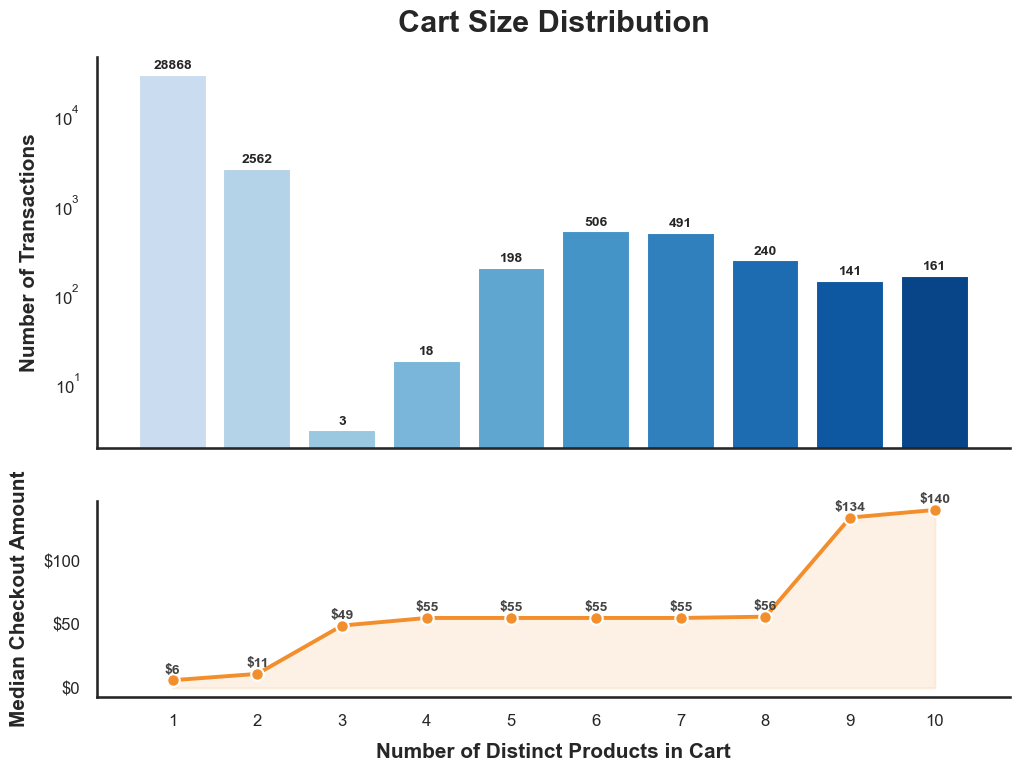

In [64]:
# ------------------------------------------------------------
# Refined cart size visualization — more visually distinct
# ------------------------------------------------------------

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# Color setup
bar_colors = sns.color_palette("Blues", n_colors=len(cart_size_summary) + 2)[2:]
line_color = "#F28E2B"   # warm orange
marker_edge = "white"

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(11, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1], "hspace": 0.18}
)

# White background for cleaner look
fig.patch.set_facecolor("white")
ax1.set_facecolor("white")
ax2.set_facecolor("white")

# -----------------------------
# Top plot: transaction counts
# -----------------------------
bars = ax1.bar(
    cart_size_summary["distinct_products"],
    cart_size_summary["transactions"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1.5
)

ax1.set_title(
    "Cart Size Distribution",
    fontsize=22,
    fontweight="bold",
    pad=18
)
ax1.set_ylabel(
    "Number of Transactions",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

# Log scale so smaller categories are visible
ax1.set_yscale("log")

ax1.tick_params(axis="x", labelsize=12)
ax1.tick_params(axis="y", labelsize=12)
ax1.grid(False)

# Light cleanup of spines
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Labels above bars
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height * 1.08,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# -----------------------------
# Bottom plot: median checkout
# -----------------------------
ax2.plot(
    cart_size_summary["distinct_products"],
    cart_size_summary["median_checkout_amount"],
    color=line_color,
    marker="o",
    linewidth=2.8,
    markersize=9,
    markerfacecolor=line_color,
    markeredgecolor=marker_edge,
    markeredgewidth=1.5
)

# Optional light fill under line
ax2.fill_between(
    cart_size_summary["distinct_products"],
    cart_size_summary["median_checkout_amount"],
    color=line_color,
    alpha=0.12
)

ax2.set_xlabel(
    "Number of Distinct Products in Cart",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)
ax2.set_ylabel(
    "Median Checkout Amount",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("${x:,.0f}"))
ax2.tick_params(axis="x", labelsize=12)
ax2.tick_params(axis="y", labelsize=12)
ax2.grid(False)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Annotate the line values
for x, y in zip(
    cart_size_summary["distinct_products"],
    cart_size_summary["median_checkout_amount"]
):
    ax2.text(
        x,
        y + 3,
        f"${y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#444444"
    )

# Make x ticks explicit integers
ax2.set_xticks(cart_size_summary["distinct_products"])

fig.subplots_adjust(
    top=0.90,
    bottom=0.10,
    left=0.12,
    right=0.95,
    hspace=0.22
)

plt.show()

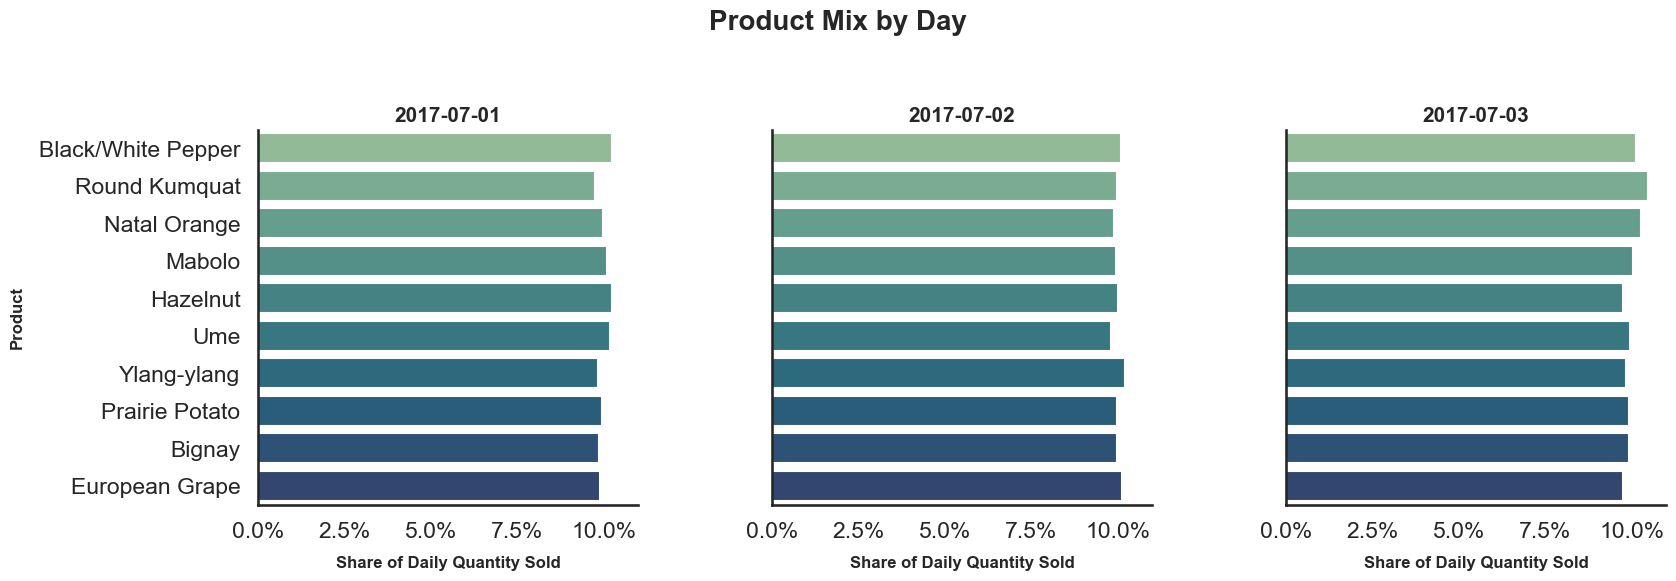

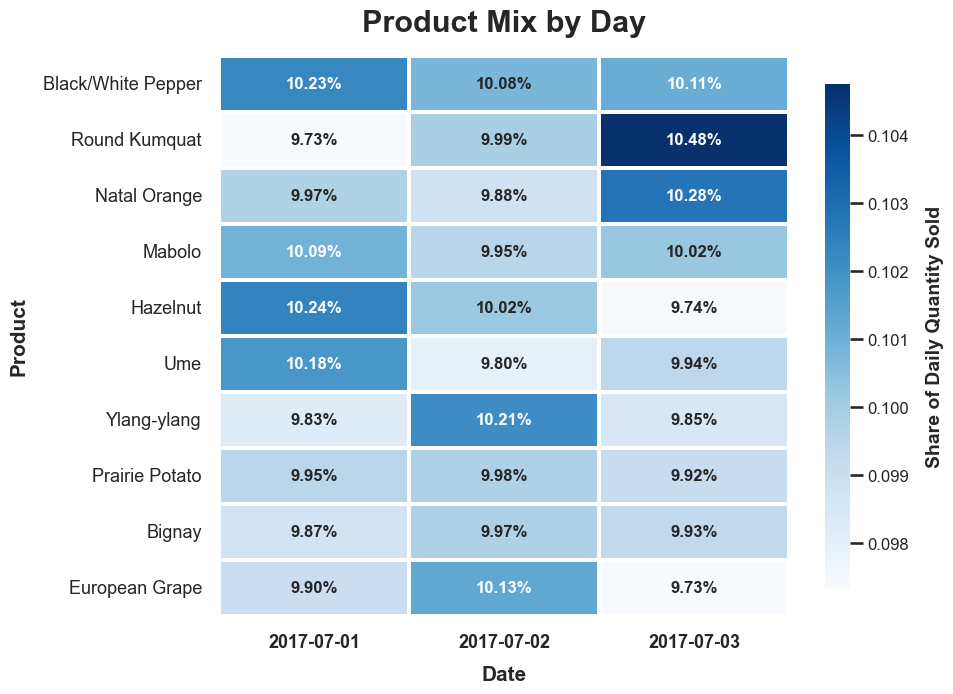

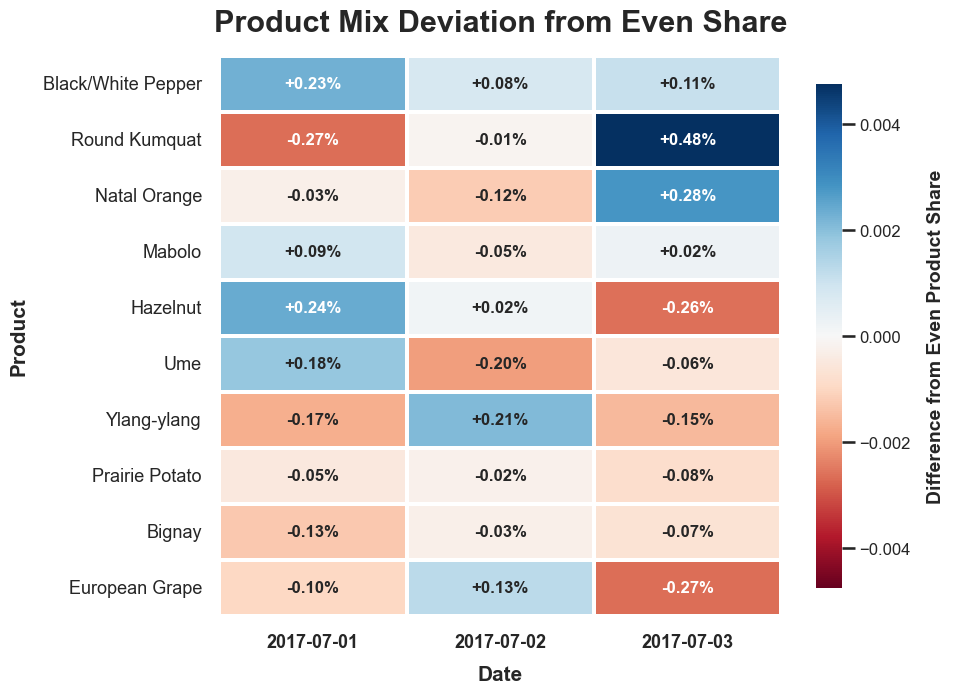

In [65]:
# ------------------------------------------------------------
# Product mix visualizations by day
# ------------------------------------------------------------

# Build daily product quantity table from parsed URL/product rows
daily_product_quantity = (
    product_df[
        (product_df["product"].notna()) &
        (product_df["product"].str.lower() != "error") &
        (product_df["quantity"].notna()) &
        (product_df["quantity"] > 0)
    ]
    .groupby(["date", "product"])
    .agg(
        total_quantity_sold=("quantity", "sum"),
        transaction_count=("transaction_index", "nunique")
    )
    .reset_index()
)

# Convert raw quantity to daily product share
daily_product_mix = daily_product_quantity.copy()

daily_product_mix["quantity_share"] = (
    daily_product_mix["total_quantity_sold"] /
    daily_product_mix.groupby("date")["total_quantity_sold"].transform("sum")
)

# Pivot for heatmaps
product_mix_pivot = (
    daily_product_mix
    .pivot_table(
        index="product",
        columns="date",
        values="quantity_share",
        aggfunc="sum"
    )
)

# Keep product order consistent: highest average share at top
product_order = (
    product_mix_pivot
    .mean(axis=1)
    .sort_values(ascending=False)
    .index
)

product_mix_pivot = product_mix_pivot.loc[product_order]


# ------------------------------------------------------------
# Plot 1: Small-multiple bar chart
# ------------------------------------------------------------

g = sns.catplot(
    data=daily_product_mix,
    kind="bar",
    x="quantity_share",
    y="product",
    hue="product",          # avoids seaborn FutureWarning
    col="date",
    order=product_order,
    hue_order=product_order,
    height=6,
    aspect=0.95,
    sharex=True,
    palette="crest",
    legend=False
)

g.set_titles("{col_name}", size=15, weight="bold")
g.set_axis_labels("Share of Daily Quantity Sold", "Product")

g.fig.subplots_adjust(wspace=0.35, top=0.78)

for ax in g.axes.flat:
    ax.grid(False)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xlabel("Share of Daily Quantity Sold", fontweight="bold", fontsize=12, labelpad=10)
    ax.set_ylabel("Product", fontweight="bold", fontsize=12, labelpad=10)

g.fig.suptitle(
    "Product Mix by Day",
    fontweight="bold",
    fontsize=20
)

plt.show()


# ------------------------------------------------------------
# Plot 2: Product mix heatmap
# Larger shares are darker; smaller shares are lighter.
# ------------------------------------------------------------

plt.figure(figsize=(10, 7.5))

ax = sns.heatmap(
    product_mix_pivot,
    annot=True,
    fmt=".2%",
    cmap="Blues",
    vmin=product_mix_pivot.min().min(),
    vmax=product_mix_pivot.max().max(),
    linewidths=1.5,
    linecolor="white",
    cbar_kws={
        "label": "Share of Daily Quantity Sold",
        "shrink": 0.9,
        "pad": 0.05
    },
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Product Mix by Day",
    fontweight="bold",
    fontsize=22,
    pad=18
)
plt.xlabel(
    "Date",
    fontweight="bold",
    fontsize=15,
    labelpad=10
)
plt.ylabel(
    "Product",
    fontweight="bold",
    fontsize=15,
    labelpad=10
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=13,
    fontweight="bold"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=13
)

# Format colorbar label and ticks
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel(
    "Share of Daily Quantity Sold",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(pad=1.5)
plt.show()


# ------------------------------------------------------------
# Plot 3: Difference from even product share
# Since there are 10 products, an even share would be 10%.
# Positive values are above even share; negative values are below.
# ------------------------------------------------------------

expected_share = 1 / product_mix_pivot.shape[0]
product_mix_deviation = product_mix_pivot - expected_share

plt.figure(figsize=(10, 7.5))

max_abs_deviation = product_mix_deviation.abs().max().max()

ax = sns.heatmap(
    product_mix_deviation,
    annot=True,
    fmt="+.2%",
    cmap="RdBu",
    center=0,
    vmin=-max_abs_deviation,
    vmax=max_abs_deviation,
    linewidths=1.5,
    linecolor="white",
    cbar_kws={
        "label": "Difference from Even Product Share",
        "shrink": 0.9,
        "pad": 0.05
    },
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    }
)

plt.title(
    "Product Mix Deviation from Even Share",
    fontsize=22,
    fontweight="bold",
    pad=18
)
plt.xlabel(
    "Date",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)
plt.ylabel(
    "Product",
    fontsize=15,
    fontweight="bold",
    labelpad=10
)

ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0,
    fontsize=13,
    fontweight="bold"
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize=13
)

# Format colorbar label/ticks
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel(
    "Difference from Even Product Share",
    fontsize=14,
    fontweight="bold",
    labelpad=12
)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout(pad=1.5)
plt.show()

<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 5: Can you predict the total sales number for 2017-07-04? How certain is the predicted number?

</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

I predict July 4 total sales will be approximately **$182,500**.

I would treat this as a low-confidence forecast, with a reasonable uncertainty range of roughly **$165,000 to $205,000**.

This is not a model-heavy forecast. With only three days of available data, a complex forecasting model would likely give a false sense of precision. Instead, I use simple baseline methods and make the assumptions explicit.

</div>

### Forecasting Approach

The prediction estimates total checkout sales for `2017-07-04`, using the cleaned and UTC-normalized transaction data from July 1 through July 3.

Because the available time window is very short, I use simple baseline forecasts rather than a more complex time-series or machine-learning model.

The baselines considered are:

| Method | Interpretation |
|:---|:---|
| **Prior-day forecast** | July 4 will look like July 3. |
| **Recent 2-day average** | July 4 will look like the average of July 2 and July 3. |
| **Transaction-based forecast** | Estimate transactions and multiply by recent average order value. |
| **Negative-value adjustment scenario** | Consider whether July 3's repeated `-12` transactions should be adjusted. |

### Why I Am Not Using a Complex Model

A more complicated model would be difficult to justify here because the dataset only contains three days of observed sales. That is not enough history to learn reliable trends, seasonality, weekday effects, holiday effects, or app-version effects.

A model could be fit technically, but it would likely be overfit and misleading. For this question, a transparent baseline forecast is more appropriate.

### Assumptions

This forecast assumes:

- The UTC-normalized transaction date is the correct date definition.
- July 4 behavior is broadly similar to July 2 and July 3.
- No major system outage occurs on July 4.
- No major app-version effect occurs on July 4.
- The repeated `-12` transactions on July 3 are not large enough to materially change the forecast.
- Large outlier purchases may occur, but cannot be predicted reliably from the available history.
- July 4 being a U.S. holiday is an important uncertainty factor, but the available dataset does not provide enough history to estimate a holiday effect directly.

### Prediction

My point estimate for July 4 total sales is:

```text
$182,500
```

My uncertainty range is:

```text
$165,000 to $205,000
```

### Certainty

I have **low to moderate confidence** in the point estimate and **higher confidence** in the broader range.

The point estimate is close to the normalized July 2 and July 3 totals, which were very similar after correcting the date-boundary issue. However, the uncertainty range is intentionally wide because daily sales are sensitive to large transactions, transaction anomalies, and the very limited number of observed days.

### Conclusion

The most defensible forecast is a simple baseline forecast around **$182,500**, not a highly tuned model.

The available data supports a prediction that July 4 will likely be in the same general range as July 2 and July 3, but the exact value is uncertain because the dataset is short, July 4 may behave differently as a holiday, and the transaction data contains outliers and anomalies.

In [66]:
# ------------------------------------------------------------
# Question 5: Simple July 4 sales forecast baselines
# ------------------------------------------------------------

forecast_date = pd.to_datetime("2017-07-04").date()

# Daily summary used for forecasting
forecast_daily = (
    df.groupby("date")
    .agg(
        transactions=("checkout_amount", "size"),
        total_sales=("checkout_amount", "sum"),
        average_order_value=("checkout_amount", "mean"),
        median_order_value=("checkout_amount", "median"),
        min_order_value=("checkout_amount", "min"),
        max_order_value=("checkout_amount", "max"),
        negative_transactions=("checkout_amount", lambda x: (x < 0).sum()),
        negative_checkout_total=("checkout_amount", lambda x: x[x < 0].sum()),
    )
    .reset_index()
    .sort_values("date")
)

forecast_daily

,date,transactions,total_sales,average_order_value,median_order_value,min_order_value,max_order_value,negative_transactions,negative_checkout_total
0,2017-07-01,9903,223515.0,22.570433,6.0,0.0,55084.0,0,0.0
1,2017-07-02,11537,183752.0,15.927191,6.0,3.0,55002.0,0,0.0
2,2017-07-03,11748,181583.0,15.456503,6.0,-12.0,60000.0,17,-204.0


In [67]:
# ------------------------------------------------------------
# Forecast candidates
# ------------------------------------------------------------

# Pull recent days
july_02 = forecast_daily.loc[forecast_daily["date"] == pd.to_datetime("2017-07-02").date()].iloc[0]
july_03 = forecast_daily.loc[forecast_daily["date"] == pd.to_datetime("2017-07-03").date()].iloc[0]

# 1. Naive forecast: tomorrow equals most recent day
naive_prior_day_forecast = july_03["total_sales"]

# 2. Average of the two most recent normalized daily totals
recent_average_forecast = forecast_daily[
    forecast_daily["date"].isin([
        pd.to_datetime("2017-07-02").date(),
        pd.to_datetime("2017-07-03").date()
    ])
]["total_sales"].mean()

# 3. Transaction-based forecast
# Use recent average transaction count and recent average order value
recent_avg_transactions = forecast_daily[
    forecast_daily["date"].isin([
        pd.to_datetime("2017-07-02").date(),
        pd.to_datetime("2017-07-03").date()
    ])
]["transactions"].mean()

recent_avg_order_value = forecast_daily[
    forecast_daily["date"].isin([
        pd.to_datetime("2017-07-02").date(),
        pd.to_datetime("2017-07-03").date()
    ])
]["average_order_value"].mean()

transaction_based_forecast = recent_avg_transactions * recent_avg_order_value

# 4. Negative-value adjustment scenario
# If the July 3 -12 transactions are treated as sign errors, July 3 increases by 408.
july_03_sign_flip_adjusted = july_03["total_sales"] + abs(july_03["negative_checkout_total"]) * 2

# Create forecast comparison table
forecast_candidates = pd.DataFrame({
    "method": [
        "Naive prior-day forecast",
        "Recent 2-day average",
        "Transaction count × recent AOV",
        "July 3 adjusted if negative values were sign errors",
    ],
    "forecasted_july_04_sales": [
        naive_prior_day_forecast,
        recent_average_forecast,
        transaction_based_forecast,
        july_03_sign_flip_adjusted,
    ]
})

forecast_candidates["forecasted_july_04_sales"] = forecast_candidates[
    "forecasted_july_04_sales"
].round(2)

forecast_candidates

,method,forecasted_july_04_sales
0,Naive prior-day forecast,181583.00
1,Recent 2-day average,182667.50
2,Transaction count × recent AOV,182692.33
3,July 3 adjusted if negative values were sign e...,181991.00


In [68]:
# ------------------------------------------------------------
# Final forecast and uncertainty range
# ------------------------------------------------------------

# Use the median of simple, reasonable baselines as the point forecast.
# This avoids over-weighting any one assumption.
final_point_forecast = forecast_candidates["forecasted_july_04_sales"].median()

# Uncertainty is intentionally wide because only 3 days are available.
# Use observed daily min/max as an empirical rough range, then round.
observed_min_sales = forecast_daily["total_sales"].min()
observed_max_sales = forecast_daily["total_sales"].max()

# A practical uncertainty range:
# Lower bound: slightly below recent observed low
# Upper bound: below July 1 extreme but allowing for outlier-driven sales
uncertainty_lower = 165_000
uncertainty_upper = 205_000

print("July 4 Sales Forecast")
print("---------------------")
print(f"Point forecast: ${final_point_forecast:,.0f}")
print(f"Uncertainty range: ${uncertainty_lower:,.0f} to ${uncertainty_upper:,.0f}")
print()
print("Forecast candidates:")
display(forecast_candidates)

July 4 Sales Forecast
---------------------
Point forecast: $182,329
Uncertainty range: $165,000 to $205,000

Forecast candidates:


,method,forecasted_july_04_sales
0,Naive prior-day forecast,181583.00
1,Recent 2-day average,182667.50
2,Transaction count × recent AOV,182692.33
3,July 3 adjusted if negative values were sign e...,181991.00


<div style="background-color:#fff3cd; padding:16px; border-left:6px solid #f0ad4e; border-radius:6px;">

## Question 6: Is there any additional information, data, or access that would make your prediction better?

</div>

<div style="background-color:#f7f7f7; padding:18px; border-left:6px solid #f28e2b; border-radius:6px;">

### Answer Summary

Yes. The forecast would be substantially better with more historical sales data, clearer timezone/date-boundary rules, product metadata, promotion/discount information, and system/app release context.

The current prediction is limited because it is based on only three days of transaction data, includes a U.S. holiday forecast date, and contains several data-quality concerns that affect revenue interpretation.

</div>

### Most Useful Additional Data

| Additional data or access | Why it would improve the prediction |
|:---|:---|
| **More historical transaction data** | Needed to estimate normal day-to-day variation, weekday patterns, holiday effects, and seasonality. |
| **Prior July 4 / holiday sales history** | July 4 may not behave like a normal day, but the current dataset does not provide enough information to estimate a holiday adjustment. |
| **Confirmed timezone and reporting rules** | Daily totals depend on how transaction dates are defined, so the reporting timezone should be explicit. |
| **Product catalog and authoritative prices** | Would confirm inferred product prices and help distinguish valid purchases from malformed URL behavior. |
| **Discounts, coupons, refunds, taxes, and shipping fields** | Would clarify whether checkout amount should equal product quantity times price, or whether other adjustments are included. |
| **App release/deployment logs** | July 3 includes an app version transition, so release timing and known issues would help diagnose whether system behavior changed. |
| **Error/logging data** | Would help explain malformed/error-like URL rows and determine whether extreme checkout values are valid. |
| **Customer/session/order identifiers** | Would help detect duplicate orders, retries, abandoned/replayed checkouts, or repeated customer behavior. |
| **Inventory or product availability data** | Would help determine whether product mix or sales volume changed due to stockouts or availability issues. |

### Why More Historical Data Matters Most

The largest limitation is the short time window. With only July 1 through July 3 available, it is not possible to reliably estimate trends, seasonality, weekday effects, or holiday behavior.

More historical data would allow the forecast to separate:

- normal daily variation,
- weekend versus weekday behavior,
- July 4 holiday effects,
- product-level seasonality,
- app-version effects,
- and the impact of outlier transactions.

Without that history, a simple baseline forecast is more defensible than a complex model.

### Why Business/System Context Matters

The transaction data also raises several interpretation questions that would benefit from system context:

- Should revenue be grouped by source file date, raw local timestamp, or UTC-normalized transaction date?
- Are negative checkout amounts valid revenue events, refunds, discounts, or logging errors?
- Should malformed/error-like URLs be excluded from product and price inference?
- Did the app version change on July 3 correspond to a known release or bug?
- Are unusually large checkout amounts valid bulk purchases?

Answers to these questions would directly affect both historical sales totals and the July 4 prediction.

### Conclusion

The most helpful improvement would be access to additional historical transaction data, especially prior holidays and comparable weekdays. I would also want explicit reporting timezone rules, product/pricing metadata, promotion/refund information, and app release logs.

With those additions, I could move from a simple baseline forecast to a more reliable model that accounts for seasonality, holidays, product mix, app-version changes, and transaction anomalies.